In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson



from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.utils.kapplan_meir import k_m_cox
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_dataset_by_ids
from src.utils.set_seed import set_seed
from src.utils.cox_models import *
from sklearn.utils import resample


import numpy as np
import torch
import torchtuples as tt

%load_ext autoreload
%autoreload 2
%matplotlib inline

c:\Users\alexf\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_seed(42)

In [3]:
pp = Preprocessor()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [5]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [6]:
# === Use the SAME 1000-gene panel as limma.ipynb (train-only limma) ===
# This notebook used to run limma on the FULL dataset (519 samples), which
# leaked ~158 of the 1000 panel genes from val+test into NN feature selection.
# We now reuse the canonical panel that limma.ipynb wrote from TRAIN+VAL only
# (n=415). That guarantees both notebooks see the same 1000 genes and that
# the 104 test patients never contribute to feature selection.
import json

with open("splits.json") as f:
    _split = json.load(f)
trainval_ids = set(_split["train_ids"]) | set(_split["val_ids"])

top_genes_limma = pd.read_csv("elasticnet_candidates.csv")["gene"].tolist()
print(f"Loaded {len(top_genes_limma)} genes from train-only limma panel (test patients excluded)")


Loaded 1000 genes from train-only limma panel (test patients excluded)


In [7]:
N_GENES = len(top_genes_limma)
print(f"N_GENES = {N_GENES} (loaded from elasticnet_candidates.csv, train-only limma)")


N_GENES = 1000 (loaded from elasticnet_candidates.csv, train-only limma)


In [8]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler, sample_ids = torch_preprocessing.get_data_set(60, return_ids=True)


Genes before Treshold: 1003
count    1003.000000
mean        0.716849
std         3.255517
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        40.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [9]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)



In [10]:
type(surival_data_set)

src.dataset.DataSet.SurvivalDataSet

In [11]:
import json
from src.dataset.split_data import split_dataset_by_ids

# Load the canonical split created by limma.ipynb so the NN uses the SAME patients.
split = json.load(open("splits.json"))
set_seed()
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_dataset_by_ids(
    surival_data_set, sample_ids,
    split["train_ids"], split["val_ids"], split["test_ids"]
)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")
print(f"Train: {type(train_X)}, Val: {type(val_X)}, Test: {type(test_X)}")

Train: 331, Val: 84, Test: 104
Train: <class 'torch.Tensor'>, Val: <class 'torch.Tensor'>, Test: <class 'torch.Tensor'>


In [12]:
in_features = train_X.shape[1]
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()



val_X_np = val_X.cpu().numpy()
val_durations_np = val_durations.cpu().numpy()
val_events_np = val_events.cpu().numpy()


test_X_np = test_X.cpu().numpy()
test_durations_np = test_durations.cpu().numpy()
test_events_np = test_events.cpu().numpy()

train_X_np.shape, train_durations_np.shape, train_events_np.shape

((331, 1000), (331,), (331,))

## DeepSurv Bootstrap

In [13]:
set_seed()
N_BOOTSTRAP = 50
gene_shap_records = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[16, 16],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0005,
            weight_decay=0.001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_checkpoint.json", "w") as f:
      json.dump(gene_shap_records, f)


PermutationExplainer explainer: 105it [03:04,  1.78s/it]                         


Bootstrap 1/50 OK


PermutationExplainer explainer: 105it [02:40,  1.66s/it]                         


Bootstrap 2/50 OK


PermutationExplainer explainer: 105it [02:40,  1.64s/it]                         


...

Bootstrap 48/50 OK


PermutationExplainer explainer: 105it [02:43,  1.67s/it]                         


Bootstrap 49/50 OK


PermutationExplainer explainer: 105it [02:41,  1.65s/it]                         


Bootstrap 50/50 OK


In [14]:
gene_shap_records["YTHDF1"]


KeyError: 'YTHDF1'

In [21]:
valid_genes = [g for g in genes_expression if len(gene_shap_records[g]) > 0]

records   = np.array([gene_shap_records[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

# Estabilidad real: coeficiente de variación (menor = más estable)
cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

# Frecuencia de aparición en el top-50 a lo largo de los bootstraps
TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df = pd.DataFrame({
    'gene':      valid_genes,
    'mean_shap': mean_shap,
    'std_shap':  std_shap,
    'cv_shap':   cv_shap,
    'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv = bootstrap_df.head(500)
boot_to_csv.to_csv("boot_strap_df_deepsurv.csv")

In [22]:
bootstrap_df

,gene,mean_shap,std_shap,cv_shap,topk_freq
47,COMMD7,0.010685,0.006362,0.595429,0.26
277,TTLL5,0.010432,0.007209,0.691045,0.14
948,VPS41,0.010331,0.006716,0.650055,0.20
584,RNF214,0.010289,0.006697,0.650876,0.12
254,SETX,0.010123,0.006267,0.619036,0.14
...,...,...,...,...,...
632,ANPEP,0.002431,0.001537,0.632226,0.00
551,CXCL13,0.002330,0.001388,0.595796,0.00
803,IL20RB,0.002173,0.003116,1.433951,0.00
842,ACHE,0.001503,0.001477,0.982544,0.00


### CoxNett DeppSurv

In [ ]:
set_seed()
N_BOOTSTRAP = 50
gene_shap_records_coxnnet = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[32],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0001,
            weight_decay=0.0001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records_coxnnet[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_coxnnet_checkpoint.json", "w") as f:
      json.dump(gene_shap_records_coxnnet, f)


NameError: name 'genes_expression' is not defined

In [ ]:
valid_genes = [g for g in gene_shap_records_coxnnet if len(gene_shap_records_coxnnet[g]) > 0]

records   = np.array([gene_shap_records_coxnnet[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df_coxnnet = pd.DataFrame({'gene': valid_genes, 'mean_shap': mean_shap,'std_shap':  std_shap, 'cv_shap':   cv_shap, 'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv_coxnnet = bootstrap_df_coxnnet.head(100)
boot_to_csv_coxnnet.to_csv("boot_strap_df_coxnnet.csv")

In [ ]:
boot_to_csv_coxnnet

,gene,mean_shap,std_shap,cv_shap,topk_freq
973,APP,0.042678,0.004750,0.111310,0.4
433,STMN3,0.042459,0.007049,0.166020,0.4
254,PDCD4,0.041551,0.008440,0.203138,0.3
103,SAFB,0.041230,0.005269,0.127784,0.2
519,CTPS2,0.041010,0.007623,0.185873,0.4
...,...,...,...,...,...
253,RPE,0.038628,0.004921,0.127389,0.2
78,MC1R,0.038612,0.004648,0.120371,0.1
907,LOC606724,0.038599,0.004235,0.109722,0.3
678,KDM6B,0.038598,0.007258,0.188044,0.1


### Consensus of the genes

In [69]:
df_coxnnet = pd.read_csv("boot_strap_df_coxnnet.csv")
df_deepsurv = pd.read_csv("boot_strap_df_deepsurv.csv")
df_elasticnet = pd.read_csv("elasticnet_genes.csv")

STABILIZER = 0.1

df_coxnnet_genes = set(df_coxnnet.loc[df_coxnnet["topk_freq"] >= STABILIZER]["gene"])
df_deepsurv_genes = set(df_deepsurv.loc[df_deepsurv["topk_freq"] >= STABILIZER]["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

consenso = df_coxnnet_genes & df_deepsurv_genes & enet_selected


solo_no_lineal = (df_coxnnet_genes & df_deepsurv_genes & enet_candidates) - enet_selected

solo_no_lineal
consenso

set()

In [125]:
TOPN = 100
df_coxnnet_genes  = set(df_coxnnet.head(TOPN)["gene"])
df_deepsurv_genes = set(df_deepsurv.head(TOPN)["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

nn_consenso = set(df_coxnnet.head(100)["gene"]) | set(df_deepsurv.head(100)["gene"])        
consenso = nn_consenso & enet_selected # el modelo lineal es tan disperso que el consenso de todos los modelos se reduce a casi nada                
solo_no_lineal = (nn_consenso & enet_candidates) - enet_selected

print(f"NN consenso: {len(nn_consenso)} -> {sorted(nn_consenso)}")
print(f"Consenso total: {len(consenso)} -> {sorted(consenso)}")
print(f"Solo no lineales: {len(solo_no_lineal)} -> {sorted(solo_no_lineal)}")


NN consenso: 185 -> ['ABHD12', 'ADD1', 'AGPAT2', 'ALAD', 'ANKRD53', 'APOO', 'APP', 'ARFRP1', 'ARMH4', 'ARV1', 'ATF2', 'B3GALNT1', 'B3GAT3', 'BRICD5', 'C16orf86', 'C18orf32', 'C1orf112', 'CA2', 'CARHSP1', 'CCDC134', 'CCDC47', 'CDC42BPG', 'CDC42EP2', 'CDH24', 'CENPO', 'CEP131', 'CEP83', 'CFB', 'CFL1', 'CMTM1', 'CNGA4', 'CSNK2A1', 'CTPS2', 'CTSO', 'DAXX', 'DDX28', 'DHX37', 'DNAJC16', 'EDN2', 'EHBP1', 'EIF2AK1', 'EMID1', 'EP300', 'EPHA10', 'ERLEC1', 'EXOSC9', 'FAHD2CP', 'FBXO43', 'FKBP9', 'FNBP4', 'FNIP1', 'FOSL2', 'FOXK2', 'FRG1', 'GAB3', 'GEMIN6', 'GGTA1P', 'GLI1', 'GLOD5', 'GMPPB', 'GPR18', 'GRAMD1A', 'H2AFV', 'HDAC10', 'HNRNPA3P1', 'HNRNPDL', 'HRSP12', 'IPW', 'JAZF1', 'KAT2B', 'KCTD2', 'KDM6B', 'KIAA0895L', 'KIAA1468', 'KLF6', 'KLHL10', 'KMT2B', 'KRBOX4', 'LAMB2', 'LAPTM4A', 'LHPP', 'LIMK2', 'LINC00339', 'LMTK3', 'LOC285074', 'LOC606724', 'LTBP4', 'LYPLAL1', 'MAP4', 'MAP4K2', 'MAPK1IP1L', 'MAPKBP1', 'MARK4', 'MATR3', 'MC1R', 'MED16', 'MGAT3', 'MID1', 'MON2', 'MPHOSPH9', 'MRPL11', 'MRPL

In [126]:
sorted(solo_no_lineal)

['ABHD12',
 'ADD1',
 'AGPAT2',
 'ALAD',
 'APOO',
 'ARFRP1',
 'ARMH4',
 'ARV1',
 'ATF2',
 'B3GALNT1',
 'B3GAT3',
 'BRICD5',
 'C16orf86',
 'C18orf32',
 'C1orf112',
 'CA2',
 'CARHSP1',
 'CCDC134',
 'CDH24',
 'CENPO',
 'CEP131',
 'CEP83',
 'CFB',
 'CMTM1',
 'CSNK2A1',
 'CTPS2',
 'CTSO',
 'DAXX',
 'DDX28',
 'DHX37',
 'DNAJC16',
 'EDN2',
 'EHBP1',
 'EIF2AK1',
 'EMID1',
 'EP300',
 'EPHA10',
 'ERLEC1',
 'EXOSC9',
 'FAHD2CP',
 'FBXO43',
 'FKBP9',
 'FNBP4',
 'FNIP1',
 'FOSL2',
 'FOXK2',
 'GAB3',
 'GEMIN6',
 'GGTA1P',
 'GLOD5',
 'GPR18',
 'GRAMD1A',
 'H2AFV',
 'HDAC10',
 'HNRNPA3P1',
 'HRSP12',
 'IPW',
 'JAZF1',
 'KCTD2',
 'KDM6B',
 'KIAA1468',
 'KLF6',
 'KRBOX4',
 'LAMB2',
 'LAPTM4A',
 'LIMK2',
 'LINC00339',
 'LMTK3',
 'LOC285074',
 'LOC606724',
 'LYPLAL1',
 'MAP4',
 'MAP4K2',
 'MAPK1IP1L',
 'MAPKBP1',
 'MARK4',
 'MC1R',
 'MED16',
 'MON2',
 'MRPL27',
 'MTHFR',
 'MZF1',
 'NAB2',
 'NDUFB2',
 'NGDN',
 'NKAPL',
 'NPR3',
 'NRD1',
 'NXN',
 'OMG',
 'OVOL2',
 'PAK1IP1',
 'PAX8',
 'PDHB',
 'PHYHD1',
 'PI

In [128]:
import gseapy as gp
from gseapy import barplot, dotplot
list_genes_sets = pd.read_csv("elasticnet_candidates.csv")


enriched_list = gp.enrichr(gene_list=sorted(solo_no_lineal),
           gene_sets=["KEGG_2021_Human","GO_Biological_Process_2023","Reactome_2022"], 
           background=list(enet_candidates),
           organism='human',
            outdir=None)


passed_values = enriched_list.results[enriched_list.results["Adjusted P-value"] < 0.05]
passed_values

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes


In [123]:
enr_genome = gp.enrichr(
    gene_list=sorted(solo_no_lineal),
    gene_sets=["KEGG_2021_Human","GO_Biological_Process_2023","Reactome_2022"],
    organism='human', outdir=None)
enr_genome.results[enr_genome.results["Adjusted P-value"] < 0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


In [122]:
passed_values, sorted(solo_no_lineal)

(Empty DataFrame
 Columns: [Gene_set, Term, P-value, Adjusted P-value, Old P-value, Old adjusted P-value, Odds Ratio, Combined Score, Genes]
 Index: [],
 ['ATF2',
  'B3GAT3',
  'C16orf86',
  'EHBP1',
  'FOXK2',
  'LAMB2',
  'MARK4',
  'OVOL2',
  'PI4KAP1',
  'RWDD2B',
  'WDR45',
  'WDR53'])

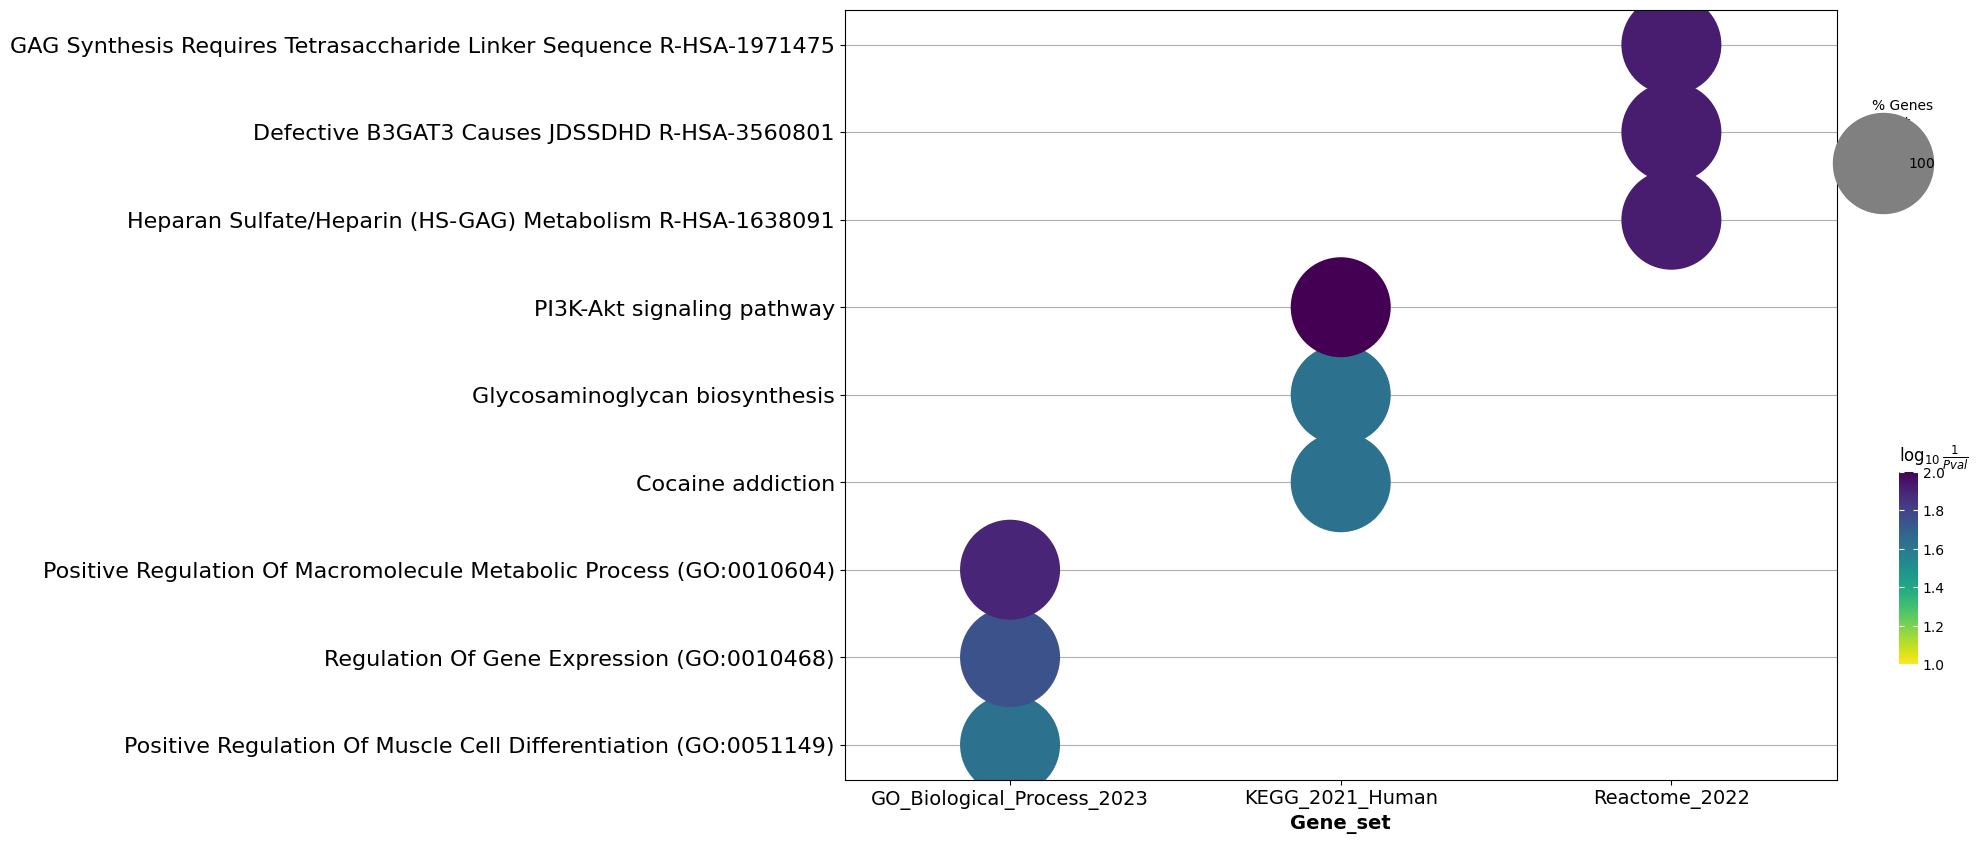

In [117]:
passed_values = (
    passed_values
    .sort_values("Adjusted P-value")
    .groupby("Gene_set")
    .head(3)
)

ax = dotplot(
    passed_values,
    column="P-value",
    x="Gene_set",
    size=12,
    top_term=5,
    figsize=(16,10),
)



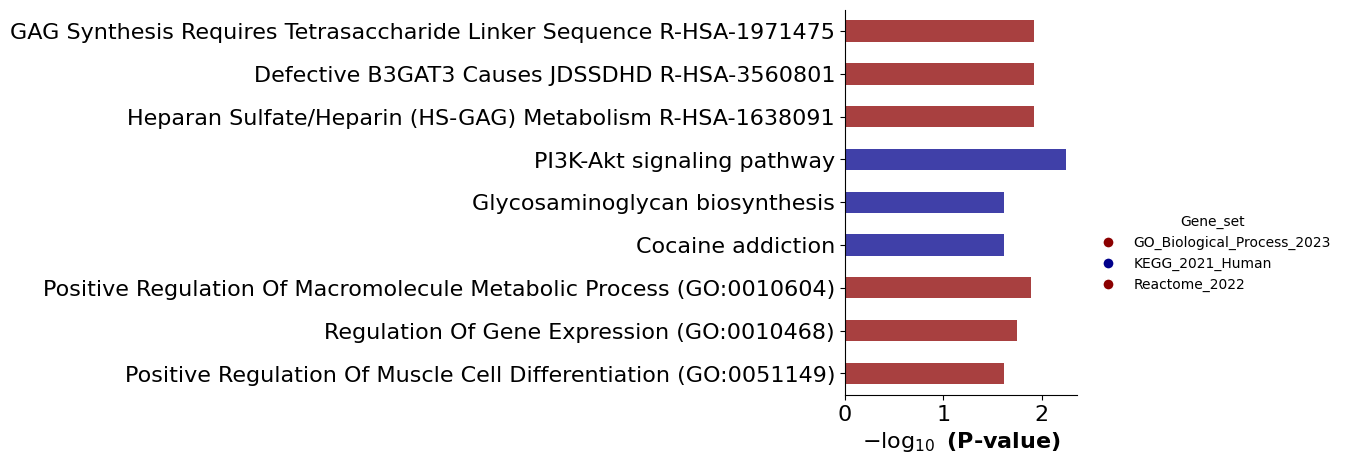

In [ ]:
ax = barplot(passed_values,
              column="P-value",
              group='Gene_set', # set group, so you could do a multi-sample/library comparsion
              size=10,
              top_term=5,
              figsize=(3,5),
              color=['darkred', 'darkblue'] # set colors for group
              )